In [36]:
import matplotlib.pyplot as plt
from IPython.display import Audio
import numpy as np
from scipy.signal import lfilter, butter, iirnotch
from scipy.io import wavfile
from scipy.fft import rfft, rfftfreq
import random

In [37]:
def get_glottal_wave_period(T, fs):
  # функция, возвращающая один период глоттальной волны
  Tp = int(0.4 * T * fs)
  Tn = int(0.16 * T * fs)
  T_ = int(T * fs)

  fp = [3 * (t / Tp) ** 2 - 2 * (t / Tp) ** 3 for t in range(Tp)]
  fn = [1 - ((t - Tp) / Tn) ** 2 for t in range(Tp, Tp + Tn)]
  f0 = [0 for t in range(Tp + Tn, T_)]

  impulse = fp + fn + f0
  return np.array(impulse)

In [38]:
def get_glottal_wave(T, fs, duration, jitter=0.05, shimmer=0.05):
  # функция, возвращающая глоттальную волну нужной длительности
  glottal_wave = []

  period_num = int(duration / T)

  for i in range(period_num):
      T_new = T + T * jitter * random.random()
      new_impulse = get_glottal_wave_period(T_new, fs) * (1 + shimmer * random.random())
      glottal_wave.extend(new_impulse)

  return glottal_wave

In [39]:
def one_band_filter(sig, F, BW, fs):
    T = 1 / fs
    B = 2 * np.exp(-np.pi * BW * T) * np.cos(2* np.pi * F * T)
    C = -np.exp(-2 * np.pi * BW * T)
    A = 1 - B - C
    return lfilter([A], [1, -B, -C], sig)

In [40]:
def filter_by_formants(formant_dict, src, fs):
  formant_freqs = formant_dict["freqs"]
  bws = formant_dict["bws"]

  result = src
  for freq, bw in zip(formant_freqs, bws):
    result = one_band_filter(result, freq, bw, fs)

  return result

In [41]:
def plot_spectrum(sig, fs, xlim=10000, log=False):
  freqs = rfftfreq(len(sig), 1/fs)
  spectrum = np.log(np.abs(rfft(sig))) if log else np.abs(rfft(sig))
  plt.plot(freqs, spectrum)
  plt.grid()
  plt.xlim(0, xlim)

In [42]:
formants = {
    "a": {
      "freqs": [620,	1220,	2550,	3300,	4500],
      "bws": [80, 100, 140, 200, 250],
    },
    "e": {
      "freqs": [550, 2000, 2600, 3450, 4700],
      "bws": [50, 80, 100, 150, 200],
    },
    "i": {
      "freqs": [300, 2200, 3000, 3700, 5000],
      "bws": [60, 110, 130, 220, 270],
    },
    "o": {
      "freqs": [500, 800, 2500, 3200, 4300],
      "bws": [50, 80, 80, 150, 200],
    },
    "u": {
      "freqs": [300, 600, 2200, 3000, 4000],
      "bws": [50, 80, 100, 170, 220],
    },
    "y": {
      "freqs": [450, 1400, 2300, 3400, 4500],
      "bws": [70, 110, 120, 200, 250],
    },
    "w": {
        "freqs": [290, 610, 2150],
        "bws": [50, 80, 60],
    },
    "j": {
        "freqs": [260, 2070, 3020],
        "bws": [40, 250, 500],
    },
    "l": {
        "freqs": [310, 1050, 2880],
        "bws": [50, 100, 280],
    },
    "m": {
        "freqs": [250, 1000, 2200],
        "bws": [50, 80, 120],
        "anti_f": 800,
        "anti_bw": 150
    },
    "n": {
        "freqs": [300, 1500, 3500],
        "bws": [60, 90, 130],
        "anti_f": 1000,
        "anti_bw": 160
    },
    "ng": {
        "freqs": [350, 1800, 2800],
        "bws": [60, 100, 130],
        "anti_f": 1500,
        "anti_bw": 200
    }
}

Задание. Напишите функцию, генерирующую носовые согласные. Сначала отфильтруйте источник по формантам, затем антиформантным фильтром.

In [43]:
def antiformant_filter(sig, F, BW):
    T = 1 / fs
    B = -2 * np.exp(-np.pi * BW * T) * np.cos(2* np.pi * F * T)
    C = np.exp(-2 * np.pi * BW * T)
    A = 1
    return lfilter([A, B, C], [1], sig)

In [44]:
def get_nasal_sound(phon, fs, f0, duration):
    source = get_glottal_wave(1 / f0, fs, duration)

    formant_freqs = formants[phon]["freqs"]
    bws = formants[phon]["bws"]

    result = source
    for freq, bw in zip(formant_freqs, bws):
      result = one_band_filter(result, freq, bw, fs)

    result = antiformant_filter(result, formants[phon]["anti_f"], formants[phon]["anti_bw"])

    return result

In [45]:
fs = 41000
f0 = 100

In [46]:
n = get_nasal_sound("n", fs, f0, 1)
m = get_nasal_sound("m", fs, f0, 1)
ng = get_nasal_sound("ng", fs, f0, 1)

In [47]:
Audio(n, rate=fs)

In [48]:
Audio(m, rate=fs)

In [49]:
Audio(ng, rate=fs)

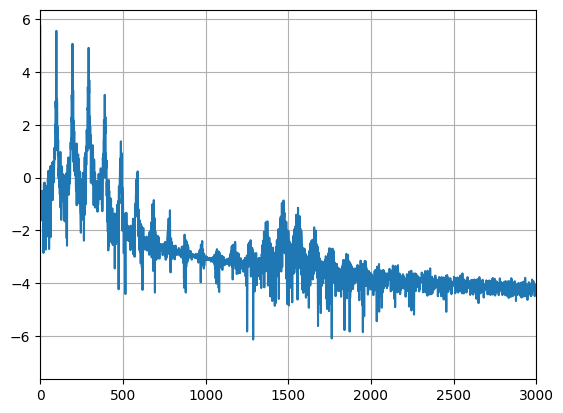

In [50]:
plot_spectrum(n, fs, xlim=3000, log=True)

Задание. Напишите функцию, генерирующую гласные и сонанты (с поддержкой носовых)

In [55]:
nasals = ("m", "n", "ng")

In [53]:
def get_sonorant_sound(phon, fs, f0, duration):
    source = get_glottal_wave(1 / f0, fs, duration)

    formant_freqs = formants[phon]["freqs"]
    bws = formants[phon]["bws"]

    result = source
    for freq, bw in zip(formant_freqs, bws):
      result = one_band_filter(result, freq, bw, fs)

    if phon in nasals:
      result = antiformant_filter(result, formants[phon]["anti_f"], formants[phon]["anti_bw"])

    return result

In [65]:
o = get_sonorant_sound("o", fs, f0, 1)
i = get_sonorant_sound("i", fs, f0, 1)

oi = np.concatenate((o, i))

In [66]:
Audio(oi, rate=fs)

In [74]:
def make_morph_sound(first_phon, second_phon, number_of_periods, f0, fs):
  result = []

  morph_formants = []
  morph_bws = []
  first_formants = formants[first_phon]["freqs"]
  sec_formants = formants[second_phon]["freqs"]

  first_bws = formants[first_phon]["bws"]
  sec_bws = formants[second_phon]["bws"]

  for i in range(number_of_periods):
    morph_formants.append([])
    morph_bws.append([])
    for j in range(min(len(first_formants), len(sec_formants))):
      morph_formants[-1].append(first_formants[j] + (i + 1) * (sec_formants[j] - first_formants[j]) / (number_of_periods + 1))
      morph_bws[-1].append(first_bws[j] + (i + 1) * (sec_bws[j] - first_bws[j]) / (number_of_periods + 1))

  for i in range(number_of_periods):
      period = get_glottal_wave_period(1/f0, fs)
      for f, bw, in zip(morph_formants[i], morph_bws[i]):
        period = one_band_filter(period, f, bw, fs)

      result = np.concatenate((result, period))

  return result


In [81]:
oi = make_morph_sound("o", "i", 100, f0, fs)

In [82]:
Audio(oi, rate=fs)